In [ ]:
import numpy as np
import cv2
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 500)
import matplotlib.patches as patches
import math
# pd.set_option('display.max_cols', 500)

096229154.jpg


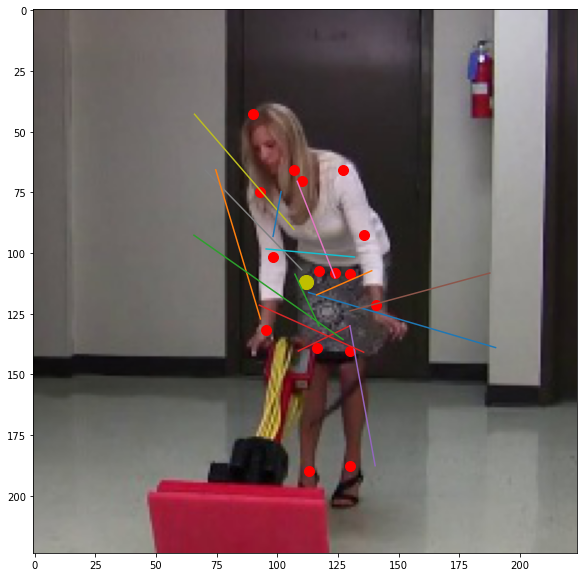

In [21]:
df = pd.read_csv('trainval_unique_cropped.csv')
sample_index = 5000
current_sample = df.iloc[sample_index] # row of dataframe
filename = current_sample[0] # name of the image file
print(filename)

images_path = "./data/mpii/images_cropped/"




full_path_image = os.path.join(images_path, filename) # full path to image file
image = cv2.cvtColor(cv2.imread(full_path_image, 1), cv2.COLOR_BGR2RGB) # image

height, width, num_chanels = image.shape


center = np.array(current_sample[1:3]).astype(np.float32) # center of human
scale = np.array(current_sample[3]).astype(np.float32) # scale of human

joints_coordinates = np.array(current_sample[4:4+32]).astype(np.float32) # 16 joints (32 coordinates)
joints_X = np.array(joints_coordinates[::2]) # (X coordinates of joints)
joints_Y = np.array(joints_coordinates[1::2]) # (X coordinates of joints
visibility_array = np.array(current_sample[36:36+16]).astype(np.int64)

display_overlaid_image(image, joints_X, joints_Y)

In [20]:
def display_overlaid_image(image, joints_X, joints_Y):
    plt.figure(figsize=(10, 10))
    image = np.array(image).astype(np.uint8)
    xs = joints_X*width
    ys = joints_Y*height
    for i in range((len(xs)-1)):
        if i==9:
            continue
    #     cv2.putText(image,"{}".format(i),(xs[i],ys[i]),cv2.FONT_HERSHEY_PLAIN,fontScale = 0.7,color = (255,255,255))
        start_point = (xs[i], ys[i]) 
        end_point = (xs[i+1],ys[i+1])
#         cv2.line(image, start_point, end_point, color=(255, 255, 0), thickness=2)
#         start_point = (ys[i], xs[i]) 
#         end_point = (ys[i+1], xs[i+1])
        plt.plot(start_point, end_point)
    
    plt.imshow(image)
    plt.scatter(joints_X*width, joints_Y*height, color='r', s=100) # joints
    plt.scatter(center[0]*width, center[1]*width, color='y', s=200) # center
    plt.show()


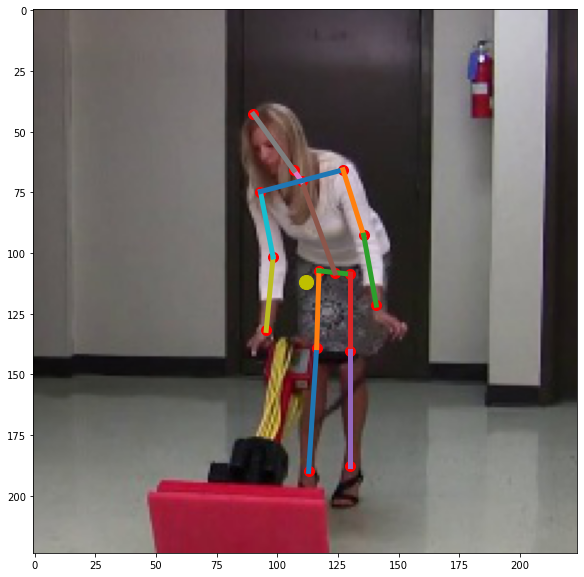

In [39]:
plt.figure(figsize=(10, 10))
image = np.array(image).astype(np.uint8)
xs = joints_X*width
ys = joints_Y*height
for i in range((len(xs)-1)):
    if i==9 or i==5:
        continue
#     cv2.putText(image,"{}".format(i),(xs[i],ys[i]),cv2.FONT_HERSHEY_PLAIN,fontScale = 0.7,color = (255,255,255))
    start_point = (xs[i], xs[i+1]) 
    end_point = (ys[i], ys[i+1])
#         cv2.line(image, start_point, end_point, color=(255, 255, 0), thickness=2)
#         start_point = (ys[i], xs[i]) 
#         end_point = (ys[i+1], xs[i+1])
    plt.plot(start_point, end_point, linewidth=5)
#     break
    

plt.imshow(image)
plt.scatter(joints_X*width, joints_Y*height, color='r', s=100) # joints
plt.scatter(center[0]*width, center[1]*width, color='y', s=200) # center
plt.show()

In [24]:
xs[0]

112.945145

In [25]:
ys[0]

189.97469